# GraphNN backend example

This notebook walks through an end-to-end workflow with the `graphnn`
backend: compile a cyclic graph, train a small model, and interpret named
nodes.

It assumes you have already read the [Getting started](getting-started.ipynb)
notebook. Here we focus on graph-defined message passing over a topology that
includes cycles and a direct input-to-output connection.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from torch import nn

import edge2torch as e2t

sns.set_theme(style="whitegrid")

## Define a cyclic message-passing graph

The `graphnn` backend preserves the original graph topology while applying
masked state updates at each step.

This example contains:

- two input features feeding separate modules
- a feedback loop between `module_a` and `module_b`
- a readout edge from `module_a` to `readout_1` for the informative branch
- a direct skip edge from `feature_b` to `readout_1` (noise shortcut)

In [2]:
edgelist = pd.DataFrame(
    {
        "source": [
            "feature_a",
            "feature_b",
            "module_a",
            "module_b",
            "module_a",
            "feature_b",
        ],
        "target": [
            "module_a",
            "module_b",
            "module_b",
            "module_a",
            "readout_1",
            "readout_1",
        ],
    }
)

edgelist

,source,target
0,feature_a,module_a
1,feature_b,module_b
2,module_a,module_b
3,module_b,module_a
4,module_a,readout_1
5,feature_b,readout_1


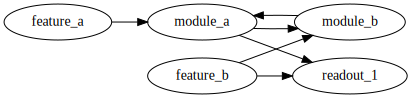

In [3]:
dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = ["feature_a", "feature_b"]
state_nodes = ["module_a", "module_b"]
output_nodes = ["readout_1"]

for node_name in input_nodes:
    dot.node(node_name, node_name)

for node_name in state_nodes:
    dot.node(node_name, node_name)

for node_name in output_nodes:
    dot.node(node_name, node_name)

for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))

dot

## Compile with `backend="graphnn"`

As with the recurrent backend, interpretation sites are exposed as
`step_1`, `step_2`, and so on.

In [4]:
model, artifact = e2t.compile_graph(
    edgelist=edgelist,
    backend="graphnn",
    steps=2,
    quiet=True,
)

artifact.backend, list(artifact.interpretation_sites.keys())

('graphnn', ['step_1', 'step_2'])

## Simulate data, align features, and train

In [5]:
def simulate_binary_data(
    n_per_class,
    feature_names,
    informative_features,
    rng,
):
    n_features = len(feature_names)
    n_samples = 2 * n_per_class

    x = rng.normal(0.0, 1.0, size=(n_samples, n_features))
    y = np.array([0] * n_per_class + [1] * n_per_class)

    informative_idx = [
        feature_names.index(feature_name)
        for feature_name in informative_features
    ]

    for class_value, shift in enumerate([-1.5, 1.5]):
        class_mask = y == class_value
        for feature_idx in informative_idx:
            x[class_mask, feature_idx] += shift

    x_df = pd.DataFrame(x, columns=feature_names)
    y_series = pd.Series(y, name="label")

    return x_df, y_series

In [6]:
rng = np.random.default_rng(1)

x_train_df, y_train = simulate_binary_data(
    n_per_class=80,
    feature_names=artifact.feature_names,
    informative_features=["feature_a"],
    rng=rng,
)

x_test_df, y_test = simulate_binary_data(
    n_per_class=40,
    feature_names=artifact.feature_names,
    informative_features=["feature_a"],
    rng=rng,
)

x_train_df.head()

,feature_a,feature_b
0,-1.154416,0.821618
1,-1.169563,-1.303157
2,-0.594644,0.446375
3,-2.036953,0.581118
4,-1.135428,0.294132


Loss before first update: 0.7283
Loss after final update:  0.1407


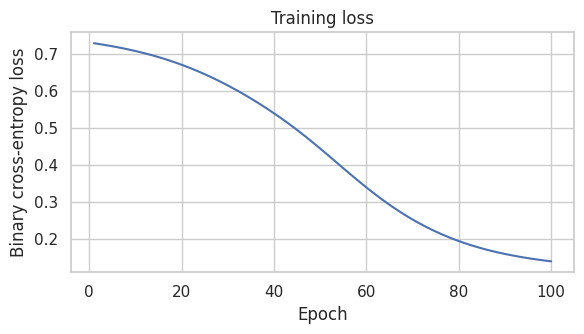

In [7]:
torch.manual_seed(0)

x_train = e2t.align_features_to_input_nodes(
    data=x_train_df,
    artifact=artifact,
)
x_test = e2t.align_features_to_input_nodes(
    data=x_test_df,
    artifact=artifact,
)

customized_model = e2t.customize_model(
    model=model,
    head=nn.Linear(1, 1),
)

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(customized_model.parameters(), lr=1e-2)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 100
loss_history = []

customized_model.train()

for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = customized_model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print("Loss before first update:", round(loss_history[0], 4))
print("Loss after final update: ", round(loss_history[-1], 4))

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, n_epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Interpret nodes

The public node-interpretation API is the same across backends.

- default: summary `DataFrame` with hidden nodes
- `level="sites"`: one table per `step_*` site
- `nodes="non_input"`: include output nodes such as `readout_1` at the
  final step

In [8]:
node_importance = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="LayerConductance",
    quiet=True,
)

node_importance.head()

,module_a,module_b
0,-3.600691,0.0
1,-5.484945,0.0
2,-3.924281,0.0
3,-5.511037,0.0
4,-4.602296,0.0


In [9]:
node_attr_by_site = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="LayerConductance",
    level="sites",
    nodes="non_input",
    quiet=True,
)

list(node_attr_by_site.keys())

['step_1', 'step_2']

In [10]:
for site_id, site_df in node_attr_by_site.items():
    print(site_id)
    display(site_df.head())

step_1


,module_a,module_b,readout_1
0,-3.600691,0.0,0.0
1,-5.484945,0.0,0.0
2,-3.924281,0.0,0.0
3,-5.511037,0.0,0.0
4,-4.602296,0.0,0.0


step_2


,module_a,module_b,readout_1
0,0.0,0.0,-4.106757
1,0.0,0.0,-5.787998
2,0.0,0.0,-4.747686
3,0.0,0.0,-5.658590
4,0.0,0.0,-3.861898


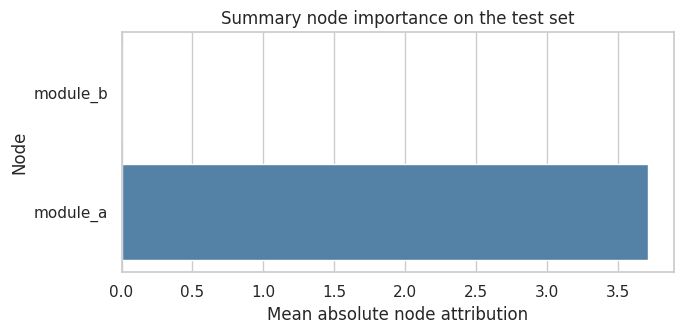

In [11]:
summary_plot = (
    node_importance.abs()
    .mean(axis=0)
    .sort_values(ascending=True)
    .rename("mean_abs_attribution")
    .reset_index()
    .rename(columns={"index": "node"})
)

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=summary_plot,
    x="mean_abs_attribution",
    y="node",
    color="steelblue",
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Summary node importance on the test set")
plt.tight_layout()
plt.show()

## Next steps

- Try different `steps` values and compare summary vs per-site results
- Read [Backends](backends.md) for graphnn semantics
- Return to [Getting started](getting-started.ipynb) for feedforward basics